**<center><font size=5>Adapting the CNN Architecture to the MNIST DIGITS DATASET</font></center>**

---

**Table of Contents**

- <a href='#intro'>1. Project Overview and Objectives</a>
  - <a href='#dataset'>1.1. Data Set Description</a>
  - <a href='#tumor'>1.2. What is Handwritten Digits Recognition?</a>
- <a href='#env'>2. Setting up the Environment</a>
- <a href='#import'>3. Data Import and Preprocessing</a>
- <a href='#cnn'>4. Building the CNN Architecture</a>
- <a href='#cnnT'>5. Model Training</a>
- <a href='#cnnE'>6. Model Evaluation</a>
- <a href='#concl'>7. Testing the model</a>
- <a href='#concC'>8. Conclusion</a>

---

All the credits goes to our TP Instructors Thanks for everything - I just adapt my personnalized thoughts and add it to the code , and share my honest work with you


# <a href='#intro'>1. Project Overview and Objectives</a>


## <a href='#dataset'>1.1. Data Set Description</a>

The MNIST (Modified National Institute of Standards and Technology) dataset is a widely used dataset for training and testing image processing systems. It consists of 70,000 images of handwritten digits (0-9), split into a training set of 60,000 images and a test set of 10,000 images. Each image is 28x28 pixels in size.

### **Description**

The MNIST dataset includes:

- **Training Images:** 60,000 images of handwritten digits.
- **Training Labels:** Corresponding labels for the training images.
- **Test Images:** 10,000 images of handwritten digits.
- **Test Labels:** Corresponding labels for the test images.
  Each image is grayscale and has been size-normalized and centered in a fixed-size image.


## <a href='#tumor'>1.2. What is Handwritten Digits Recongnition ?</a>

Handwritten digit recognition is the ability of machines to identify and classify human-written digits from images, documents, or touch screens. It uses AI, specifically machine learning and deep learning (like CNN), to convert scanned, often inconsistent, handwriting into digital text. It is widely used in banking, postal services, and OCR applications.

### Key Details About Handwritten Digit Recognition

- **Core Objective:**
  To classify images of digits (0-9) into their corresponding numerical labels.
- **Dataset:**
  Commonly uses the MNIST dataset, which contains 70,000 pixel grayscale images of handwritten digits.
- **Technologies Used:** The most effective approaches are Deep Learning models, particularly Convolutional Neural Networks (CNNs), which often achieve high accuracy. Other methods include K-Nearest Neighbors (KNN), Support Vector Machines (SVM), and Neural Networks.
- **Applications:**
- **Banking:**
  Reading check amounts.
  Postal Services: Sorting mail by recognizing zip codes.
  Data Entry: Converting handwritten forms into digital format.
- **Challenges:** Due to variations in writing styles, the system must handle inconsistencies in stroke, size, and slant.

Before having CNN we had this Fully connected neurons Architecture

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*zXPi1wzo6sjmk3lbuMdwBA.png" alt="RNN Architecture" width="700"/>

Source: [Medium](https://medium.com/@robin5002234/handwritten-digit-recognition-with-neural-networks-from-theory-to-implementation-bb12b9bf13e3)

And then things got better and CNN helped us level up from this to this :

<img src="https://www.researchgate.net/profile/B-Mesman/publication/220785200/figure/fig1/AS:340720692023305@1458245551937/An-Example-CNN-architecture-for-a-handwritten-digit-recognition-task.png" alt="CNN Architecture" width="700"/>

Source: [Research Gate](https://www.researchgate.net/figure/An-Example-CNN-architecture-for-a-handwritten-digit-recognition-task_fig1_220785200)

And I can tell you that the second one is PERFECT !


# <a href='#env'>2. Setting up the Environment</a>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# <a href='#import'>3. Data Import and Preprocessing</a>


In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets

In [ ]:
print(X_train.shape)  # shape of the Data
print(np.unique(y_train))  # print the list of possible classes

(60000, 28, 28)
[0 1 2 3 4 5 6 7 8 9]


In [4]:
# Normalisation
X_train = X_train / 255.0
X_test = X_test / 255.0

# Ajout d'une dimension channel
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [ ]:
X_train.shape  # see the 4th axis added

(60000, 28, 28, 1)

# <a href='#cnn'>4. Building the CNN Architecture</a>


In [ ]:
# Architecture
input_shape = (28, 28, 1)
activation_funct = "relu"
kernel_shape = (3, 3)
model = keras.Sequential(
    [
        keras.layers.Conv2D(
            16, (3, 3), activation=activation_funct, input_shape=input_shape
        ),
        keras.layers.MaxPooling2D((2, 2), strides=2),  # TODO: Try Average pooling
        keras.layers.Conv2D(32, kernel_shape, activation=activation_funct),
        keras.layers.MaxPooling2D((2, 2), strides=2),  # TODO: Try Average pooling
        keras.layers.Flatten(),
        keras.layers.Dense(
            64,
            activation="relu",
            kernel_initializer="he_normal",
            bias_initializer="zeros",
        ),
        keras.layers.Dense(10, activation="softmax"),
    ]
)


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

c:\Users\OMEN\miniconda3\envs\TS_Model\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

# <a href='#cnnT'>5. Model Training</a>


In [23]:
# Training
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9358 - loss: 0.2220 - val_accuracy: 0.9792 - val_loss: 0.0736
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9795 - loss: 0.0676 - val_accuracy: 0.9847 - val_loss: 0.0569
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.9878 - val_loss: 0.0471
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9876 - loss: 0.0395 - val_accuracy: 0.9878 - val_loss: 0.0442
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9896 - loss: 0.0331 - val_accuracy: 0.9900 - val_loss: 0.0397


In [24]:
# prediction
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# <a href='#cnnE'>6. Model Evaluation</a>


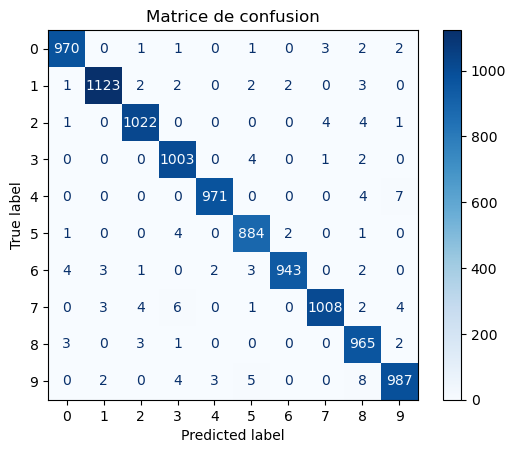


Classification Report :

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.97      0.99      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Accuracy : 0.9876


In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

# Precision / Recall / F1
print("\nClassification Report :\n")
print(classification_report(y_test, y_pred))

# Accuracy
accuracy = np.mean(y_pred == y_test)
print("\nAccuracy :", accuracy)

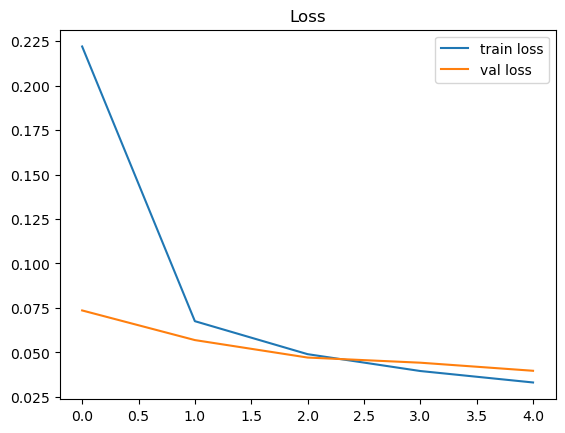

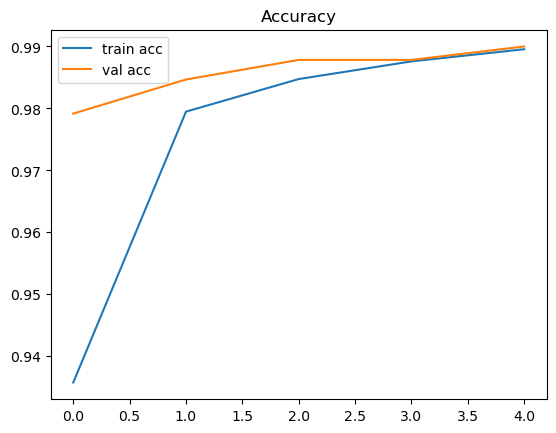

In [26]:
# Learning plots
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# <a href='#concl'>7. Testing the model</a>


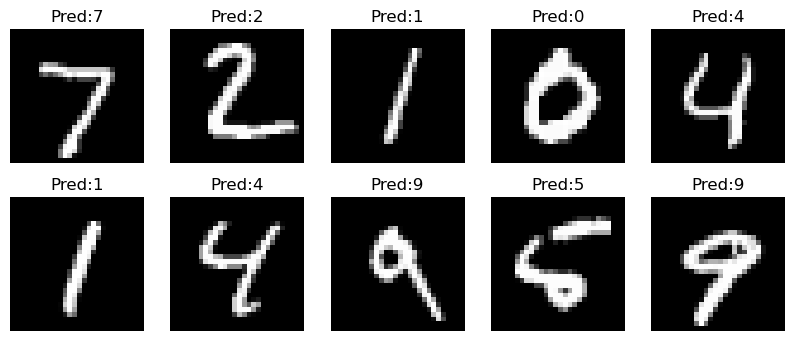

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred:{y_pred[i]}")
    ax.axis("off")

plt.show()

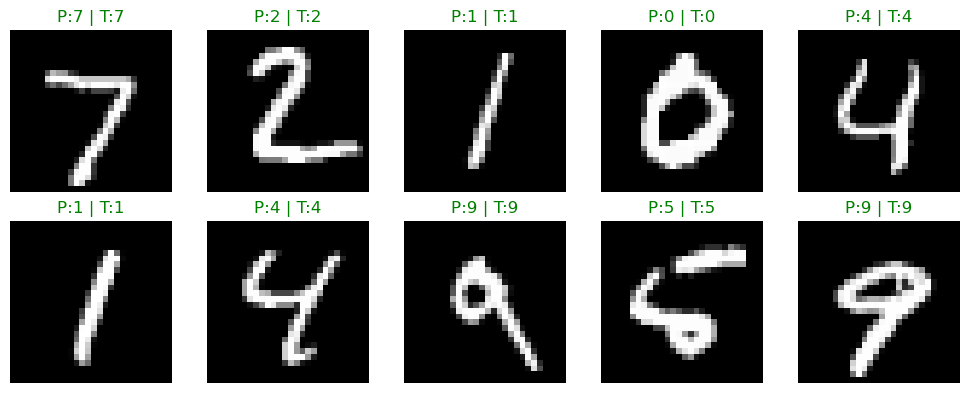

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")

    pred = y_pred[i]
    true = y_test[i]

    color = "green" if pred == true else "red"
    ax.set_title(f"P:{pred} | T:{true}", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

# <a href='#concC'>8. Conclusion</a>
